## Simulate n replicate Wright-Fisher drift trajectories

In [13]:
%matplotlib inline
import numpy as np

In [14]:
import matplotlib.pyplot as plt

In [39]:
def wright_fisher_sim(N=100, p0=0.5, generations=100, replicates =5):
    results =[]
    for rep in range(replicates):
        freqs = [p0]
        p=p0
        for _ in range(generations):
            count_A =np.random.binomial(2*N,p)
            p=count_A / (2*N)
            freqs.append(p)
        results.append(freqs)
    return results

In [57]:
#run simulations
sim_results = wright_fisher_sim(N=100, p0=0.65, generations=300, replicates=15)

In [58]:
for i, freqs in enumerate(sim_results):
    final_freq=freqs[-1]
    status = "Fixed" if final_freq == 1 else "Lost" if final_freq == 0 else "Segregating"
    print(f"rep{i+1} final freq: {final_freq:.2f} -> {status}")

rep1 final freq: 0.88 -> Segregating
rep2 final freq: 1.00 -> Fixed
rep3 final freq: 1.00 -> Fixed
rep4 final freq: 0.66 -> Segregating
rep5 final freq: 1.00 -> Fixed
rep6 final freq: 0.00 -> Lost
rep7 final freq: 1.00 -> Fixed
rep8 final freq: 1.00 -> Fixed
rep9 final freq: 0.10 -> Segregating
rep10 final freq: 0.00 -> Lost
rep11 final freq: 1.00 -> Fixed
rep12 final freq: 0.00 -> Lost
rep13 final freq: 1.00 -> Fixed
rep14 final freq: 0.00 -> Lost
rep15 final freq: 1.00 -> Fixed


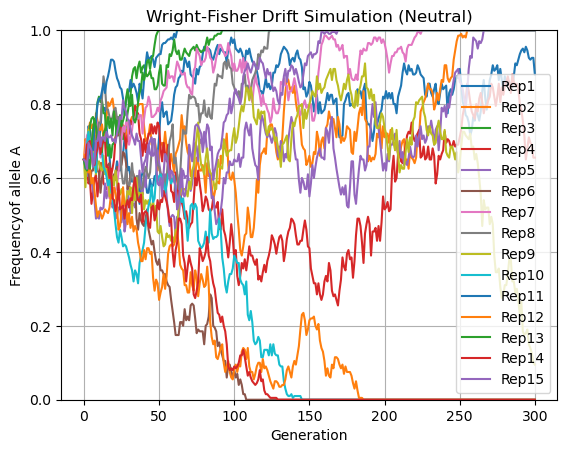

In [59]:
#plot
for i, freqs in enumerate(sim_results):
    
    plt.plot(freqs, label=f'Rep{i+1}')
plt.xlabel('Generation')
plt.ylabel('Frequencyof allele A')
plt.title('Wright-Fisher Drift Simulation (Neutral)')
plt.legend()
plt.ylim(0,1)
plt.axhline(1,color='gray', linestyle='--' , linewidth=0.5)
plt.axhline(0,color='gray', linestyle='--', linewidth=0.5)
plt.grid(True)
plt.show()

In [60]:
for i, f in enumerate(sim_results):
    print(f"Rep {i+1} final freq: {f[-1]:.2f}")

Rep 1 final freq: 0.88
Rep 2 final freq: 1.00
Rep 3 final freq: 1.00
Rep 4 final freq: 0.66
Rep 5 final freq: 1.00
Rep 6 final freq: 0.00
Rep 7 final freq: 1.00
Rep 8 final freq: 1.00
Rep 9 final freq: 0.10
Rep 10 final freq: 0.00
Rep 11 final freq: 1.00
Rep 12 final freq: 0.00
Rep 13 final freq: 1.00
Rep 14 final freq: 0.00
Rep 15 final freq: 1.00


# now including fixation differences to the wright-fisher simulator

In [61]:
def wright_fisher_selection(N=100,p0=0.5, s=0.1, generations=100, replicates=5):
    results=[]
    for rep in range(replicates):
        freqs=[p0]
        p=p0
        for _ in range(generations):
            #relative fitness of alleles A (benefiacial) and a (neutral)
            w_A = 1+s
            w_a =1

            # expected frequency of A after selection
            p_sel =(p * w_A) / (p * w_A + (1-p) * w_a)

            # sample next generation with drift
            count_A =  np.random.binomial(2*N, p_sel)
            p=count_A/ (2*N)
            freqs.append(p)
        results.append(freqs)
    return results

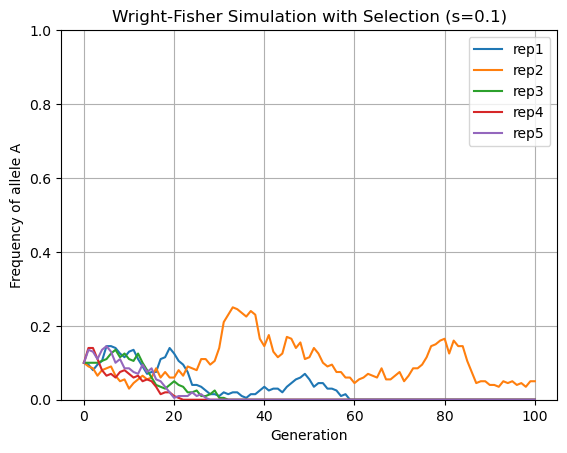

In [83]:
sim_results_sel = wright_fisher_selection(N=100, p0=0.1, s=-0.06, generations=100, replicates=5)

#positive selection  = 0.1
#negative selection  = -0.1
#s = 0 ( neutral drift )

for i, freqs in enumerate(sim_results_sel):
    plt.plot(freqs, label = f'rep{i+1}')
plt.xlabel('Generation')
plt.ylabel('Frequency of allele A')
plt.title('Wright-Fisher Simulation with Selection (s=0.1)')
plt.ylim(0,1)
plt.axhline(1, color ='gray', linestyle='--',linewidth=0.5)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.show()


#estimating fixation probability empirically

In [92]:
def fixation_rate(N=100, p0=0.01, s=0.1, generations=500, replicates = 1000):
    fix=0
    for _ in range(replicates):
        freqs = wright_fisher_selection(N, p0, s, generations, replicates=1)[0]
        if freqs[-1]==1.0:
            fix += 1
    return fix/ replicates

In [99]:
print("Fixation rate for s=0.1: " , fixation_rate(s=0.1))

Fixation rate for s=0.1:  0.316


SyntaxError: unexpected character after line continuation character (782210281.py, line 1)